<a href="https://colab.research.google.com/github/oliviategh-pixel/AH2179-Assignment-4/blob/main/Exercise7_Neural_Networks_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Neural Network**
Bike sharing systems are new generation of traditional bike rentals where whole process from membership, rental and return back has become automatic. Through these systems, user is able to easily rent a bike from a particular position and return back at another position. Currently, there are about over 500 bike-sharing programs around the world which is composed of over 500 thousands bicycles. Today, there exists great interest in these systems due to their important role in traffic, environmental and health issues.

Apart from interesting real world applications of bike sharing systems, the characteristics of data being generated by these systems make them attractive for the research. Opposed to other transport services such as bus or subway, the duration of travel, departure and arrival position is explicitly recorded in these systems. This feature turns bike sharing system into a virtual sensor network that can be used for sensing mobility in the city. Hence, it is expected that most of important events in the city could be detected via monitoring these data.

# **TASK 1: Develop the neural network model for predicting the count of rental bikes.​**
As experienced in regression exercise, the regression models did not perform well on the task of the count of rental bikes prediction. We look into the deep learing and This task will use the simple 2-layers fully connected neural network model as the example and guide you through the step-by-step process of the whole process of the model development.


## Load and prepare the data
Start by loading the dataset and shaping it so that it's suitable for use in machine learning. This dataset contains the hourly and daily count of rental bikes between years 2011 and 2012 in Capital bikeshare system with the corresponding weather and seasonal information.

In [5]:
import pandas as pd
from sympy.printing.tensorflow import tensorflow

# Define the URL from which to fetch the CSV data.
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_7_Neural_networks/Exercise7BikeSharing.csv'

# Use pandas to read the CSV data from the specified URL and store it in a DataFrame 'df'.
#df = pd.read_csv(url)
# Display the first 10 rows of the DataFrame 'df'.
df = pd.read_csv('Exercise7BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


How many rows and columns does the dataset contain?

In [6]:
df.shape

(17379, 17)

Are any of the columns missing values?

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Feature engineering
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
target = 'cnt'
features = [
    'temp','atemp','hum','windspeed','weathersit',
    'hr','weekday','workingday','holiday','season','yr'
]

X = df[features].copy()
y = df[target].astype(float)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features (important for NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**(Optional) quick baseline (Linear Regression)**

In [10]:
# A super-fast baseline, just for context
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

# Train the linear regression model
lr.fit(X_train_scaled, y_train)

# Predict the test data
y_pred_lr = lr.predict(X_test_scaled)

# Evaluation metrics
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print({
    "LR_RMSE": rmse_lr,
    "LR_MAE": mae_lr,
    "LR_R2": r2_lr
})

{'LR_RMSE': 139.20960076354183, 'LR_MAE': 104.79577059911452, 'LR_R2': 0.3879974354720257}


## Create a neural network model
Now it's time build a neural network and train it with the data prepared in the previous exercise. We'll try neural network first and use cross-validation its meaasure accuracy.

In [11]:
#pip install tensorflow

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create a Sequential model, which is a linear stack of layers.
model = Sequential()
# Add a Dense layer with 32 units, ReLU activation, and an input dimension of 11.
model.add(Dense(32, activation='relu', input_dim=11))
# Add another Dense layer with 64 units and ReLU activation.
model.add(Dense(64, activation='relu'))
# Add a final Dense layer with 1 unit (typically used for regression tasks).
model.add(Dense(1))
# Compile the model with the Adam optimizer, Mean Absolute Error (MAE) loss function,
# and MAE metric to be used during training.
model.compile(optimizer='adam', loss='mae', metrics=['mae'])
# Display a summary of the model architecture, including the number of parameters.
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)

## Training and prediction
We split the dataset into a training and a test dataset. Then, we fit the neural network model with the training dataset and predict the values for the test dataset.

Epoch 1/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 142.8039 - mae: 142.8039 - val_loss: 101.5110 - val_mae: 101.5110
Epoch 2/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 100.4227 - mae: 100.4227 - val_loss: 98.2386 - val_mae: 98.2386
Epoch 3/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 98.7386 - mae: 98.7386 - val_loss: 97.4860 - val_mae: 97.4860
Epoch 4/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 97.9219 - mae: 97.9219 - val_loss: 96.6411 - val_mae: 96.6411
Epoch 5/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 97.1142 - mae: 97.1142 - val_loss: 95.8561 - val_mae: 95.8561
Epoch 6/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 96.1077 - mae: 96.1077 - val_loss: 94.7379 - val_mae: 94.7379
Epoch 7/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 94.4671 - mae: 94.4671 - val_loss: 92.8884 - val_mae: 92.8884
Epoch 8/200
348/348 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 91.9280 - mae: 91.9280 - val_loss: 89.8858 - val_mae: 89.8858
Epoch 9/20

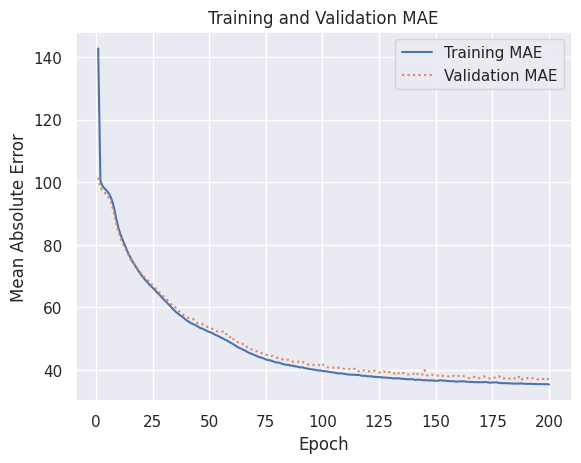

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Fit the model to the training data, specifying validation split, epochs, and batch size.
hist = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=200, batch_size=32)
# Set the style of the plots using Seaborn.
sns.set()
# Extract the training and validation Mean Absolute Error (MAE) from the training history.
err = hist.history['mae']
val_err = hist.history['val_mae']
# Define the number of epochs.
epochs = range(1, len(err) + 1)
# Plot the Training MAE and Validation MAE over epochs.
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.plot()
# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

## Evaluate the model
You can evaluate the model's performance using various metrics, such as Mean Absolute Error (MAE), Mean Squared Error (MSE), or R-squared (R2).

In [15]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Calculate the Mean Absolute Error (MAE) between the true and predicted values.
mae_nn = mean_absolute_error(y_test, y_pred)

# Calculate the Root Mean Squared Error (RMSE) between the true and predicted values.
rmse_nn = root_mean_squared_error(y_test, y_pred)

# Calculate the R-squared (R2) score, a measure of how well the model explains the variance in the data.
r2_nn = r2_score(y_test, y_pred)

# Print the calculated metrics.
print(f"Mean Absolute Error of NN: {mae_nn}")
print(f"Root Mean Squared Error of NN: {rmse_nn}")
print(f"R-squared of NN: {r2_nn}")

Mean Absolute Error of NN: 36.54830222688744
Root Mean Squared Error of NN: 62.01073754818199
R-squared of NN: 0.8785636627166646


## Compare Metrics (optional)
we compare the performance of NN with baseline linear regression.

In [16]:
import pandas as pd
results = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr},
    {'Model': 'Neural Net', 'RMSE': rmse_nn, 'MAE': mae_nn, 'R2': r2_nn},
])
results

,Model,RMSE,MAE,R2
0,Linear Regression,139.209601,104.795771,0.387997
1,Neural Net,62.010738,36.548302,0.878564


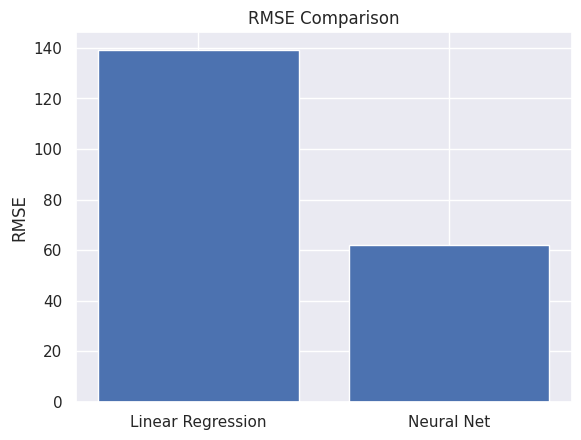

In [17]:
# Bar chart of RMSE
plt.figure()
plt.bar(results['Model'], results['RMSE'])
plt.ylabel('RMSE')
plt.title('RMSE Comparison')
plt.show()

# **Task 2: Practical NN training techniques**
The task will illustrate some useful NN training techniques, including saving and loading the trained model, using the callback function to save the best model, and adding dropout layers.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,561 (10.00 KB)

 Trainable params: 2,561 (10.00 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: val_mae improved from None to 102.09029, saving model to weights.best.keras

Epoch 1: finished saving model to weights.best.keras

Epoch 2: val_mae improved from 102.09029 to 98.73023, saving model to weights.best.keras

Epoch 2: finished saving model to weights.best.keras

Epoch 3: val_mae improved from 98.73023 to 97.73184, saving model to weights.best.keras

Epoch 3: finished saving model to weights.best.keras

Epoch 4: val_mae improved from 97.73184 to 96.93166, saving model to weights.best.keras

Epoch 4: finished saving model to weights.best.keras

Epoch 5: val_mae improved from 96.93166 to 95.95342, saving model to weights.best.keras

Epoch 5: finished saving model to weights.best.keras

Epoch 6: val_mae improved from 95.95342 to 93.93427, saving model to weights.best.keras

Epoch 6: finished saving model to weights.best.keras

Epoch 7: val_mae improved from 93.93427 to 91.15398, saving model to weights.best.keras

Epoch 7: finished saving model to weights.best.keras



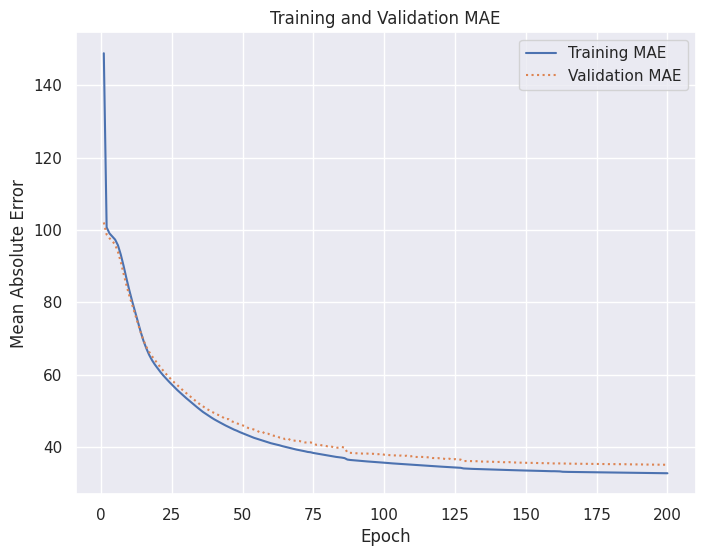

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--------------------------------------this is result of the trained model---------------------------------------------
Mean Absolute Error: 33.34231271924852
Root Mean Squared Error: 55.0441606713883
R-squared: 0.9043164293107002
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--------------------------------------this is result of the model loaded from the local path---------------------------------------------
Mean Absolute Error: 33.34231271924852
Root Mean Squared Error: 55.0441606713883
R-squared: 0.9043164293107002


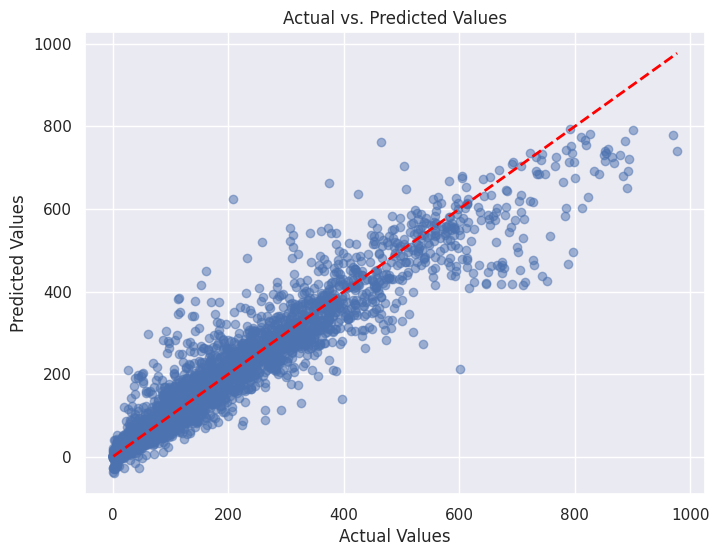

In [19]:
from json import load
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


#-------------------------------------------------reproducibility------------------------------------------------------------------

# Set a fixed random seed so that model comparisons are more reproducible.
tf.keras.utils.set_random_seed(42)


#-------------------------------------------------data preprocessing------------------------------------------------------------------

# Data preprocessing has already been completed above in the notebook.
# We use:
# X_train_scaled
# X_test_scaled
# y_train
# y_test


#-------------------------------------------------network construction-----------------------------------------------------------------

# Baseline neural network: no dropout yet.
# We will use this as the reference model before tuning network size and dropout.

def construct_network_model():

    # Create a Sequential model, which is a linear stack of layers.
    model = Sequential()

    # Define the number of input features automatically.
    model.add(Input(shape=(X_train_scaled.shape[1],)))

    # First hidden layer with 32 neurons and ReLU activation.
    model.add(Dense(32, activation='relu'))

    # No dropout in the baseline model.
    # model.add(Dropout(0.5))

    # Second hidden layer with 64 neurons and ReLU activation.
    model.add(Dense(64, activation='relu'))

    # No dropout in the baseline model.
    # model.add(Dropout(0.5))

    # Final output layer with 1 neuron for regression.
    model.add(Dense(1))

    return model


# Construct the model.
model = construct_network_model()

# Compile the model with the Adam optimizer,
# Mean Absolute Error (MAE) loss function,
# and MAE metric.
model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

# Display the model structure.
model.summary()


#-------------------------------------------------model train------------------------------------------------------------------

# Use callback functions for early stopping,
# learning-rate adjustment, and saving the best model.

# Stop training if validation MAE does not improve
# for 5 consecutive epochs and restore the best weights.
early_stop = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True
)

# Reduce the learning rate by a factor of 0.5
# if validation MAE does not improve for 3 consecutive epochs.
reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3
)

# Define the file path where the best model will be saved.
filepath = "weights.best.keras"

# Save the model whenever validation MAE improves.
checkpoint = ModelCheckpoint(
    filepath,
    monitor='val_mae',
    verbose=1,
    save_best_only=True,
    mode='min'
)

# Train the model.
hist_2 = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)


#-------------------------------------------------model evaluation--------------------------------------------------------------------

# Set the style of the plots using Seaborn.
sns.set()

# Extract the training and validation MAE from the training history.
err = hist_2.history['mae']
val_err = hist_2.history['val_mae']

# Define the number of epochs actually completed.
epochs = range(1, len(err) + 1)

# Plot Training MAE and Validation MAE over epochs.
plt.figure(figsize=(8, 6))
plt.plot(epochs, err, '-', label='Training MAE')
plt.plot(epochs, val_err, ':', label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.legend(loc='upper right')
plt.show()

# Use the trained model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate MAE, RMSE, and R-squared.
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('--------------------------------------' +
      'this is result of the trained model' +
      '---------------------------------------------')

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


#-------------------------------------------------load model and evaluation--------------------------------------------------------------------

if filepath != "":

    # Load the best saved model.
    model = load_model(filepath)

    # Use the loaded model to predict on the test data.
    y_pred = model.predict(X_test_scaled)

    # Calculate MAE, RMSE, and R-squared.
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print('--------------------------------------' +
          'this is result of the model loaded from the local path' +
          '---------------------------------------------')

    print(f"Mean Absolute Error: {mae}")
    print(f"Root Mean Squared Error: {rmse}")
    print(f"R-squared: {r2}")

    # Create a scatter plot to visualize actual vs predicted values.
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, alpha=0.5)

    # Add labels and title.
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs. Predicted Values")

    # Add a diagonal line for reference (perfect predictions).
    plt.plot(
        [min(y_test), max(y_test)],
        [min(y_test), max(y_test)],
        linestyle='--',
        color='red',
        lw=2
    )

    # Show the plot.
    plt.show()

# **Task 3: Compare the results with a linear regression model**
The task involves comparing the results obtained from the neural network with those from the linear regression model, and we should analyze the reasons behind any differences in the outcomes.

In [20]:
%matplotlib inline
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# Set the style of the plots using seaborn.
sns.set()

# Use the trained neural network model to predict on the test data.
y_pred = model.predict(X_test_scaled)

# Calculate MAE, RMSE, and R-squared for the neural network predictions.
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(
    '--------------------------------------'
    + 'this is result of the neural network model'
    + '---------------------------------------------'
)

# Print the evaluation metrics.
print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")


# Create a Linear Regression model.
model_linear = LinearRegression()

# Train the Linear Regression model.
model_linear.fit(X_train_scaled, y_train)

# Predict on the test data.
y_pred_linear = model_linear.predict(X_test_scaled)

# Calculate MAE, RMSE, and R-squared for the Linear Regression predictions.
mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = root_mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(
    '--------------------------------------'
    + 'this is result of the linear regression model'
    + '---------------------------------------------'
)

print(f"Mean Absolute Error of linear model: {mae_linear}")
print(f"Root Mean Squared Error of linear model: {rmse_linear}")
print(f"R-squared of linear model: {r2_linear}")

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--------------------------------------this is result of the neural network model---------------------------------------------
Mean Absolute Error: 33.34231271924852
Root Mean Squared Error: 55.0441606713883
R-squared: 0.9043164293107002
--------------------------------------this is result of the linear regression model---------------------------------------------
Mean Absolute Error of linear model: 104.79577059911452
Root Mean Squared Error of linear model: 139.20960076354183
R-squared of linear model: 0.3879974354720257


# **Assignment task: Find the best neural network model for the count of rental bikes prediction (assignment submission)**
Tuning the neural network models (e.g., dropout, sizing of the network), and finding the best neural network model. Suggestions:
- Try adding interaction features (e.g., `hr * workingday`, `weathersit * hum`).
- Tune NN hyperparameters (layers, neurons, learning rate) via `GridSearchCV`.
- Consider more advanced architectures (e.g., gradient boosting, LSTMs for temporal structure).

In [21]:
# ============================================================
# Assignment 4 - Stage 1: Compare neural network architectures
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K


# Architectures to compare
architectures = [
    (32, 64),      # Current baseline
    (64, 64),
    (64, 128),
    (128, 64),
    (128, 128)
]


# Store results from each model
architecture_results = []


for architecture in architectures:

    # Clear previous model from memory
    K.clear_session()

    # Use the same seed for every experiment
    # so the comparison is more reproducible.
    tf.keras.utils.set_random_seed(42)

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model_arch = Sequential([
        Input(shape=(X_train_scaled.shape[1],)),
        Dense(architecture[0], activation='relu'),
        Dense(architecture[1], activation='relu'),
        Dense(1)
    ])

    model_arch.compile(
        optimizer='adam',
        loss='mae',
        metrics=['mae']
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stop = EarlyStopping(
        monitor='val_mae',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=3
    )

    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    history_arch = model_arch.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    # --------------------------------------------------------
    # Record validation results
    # --------------------------------------------------------

    val_mae_history = history_arch.history['val_mae']

    best_val_mae = min(val_mae_history)
    best_epoch = np.argmin(val_mae_history) + 1
    epochs_trained = len(val_mae_history)

    architecture_results.append({
        'Architecture': f'{architecture[0]} -> {architecture[1]}',
        'Parameters': model_arch.count_params(),
        'Epochs trained': epochs_trained,
        'Best epoch': best_epoch,
        'Best validation MAE': best_val_mae
    })

    print(
        f"Finished {architecture[0]} -> {architecture[1]} | "
        f"Best validation MAE: {best_val_mae:.4f}"
    )


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

architecture_results_df = pd.DataFrame(architecture_results)

# Sort from lowest (best) validation MAE to highest
architecture_results_df = architecture_results_df.sort_values(
    by='Best validation MAE'
).reset_index(drop=True)

architecture_results_df

Finished 32 -> 64 | Best validation MAE: 35.0489
Finished 64 -> 64 | Best validation MAE: 32.2398
Finished 64 -> 128 | Best validation MAE: 32.4739
Finished 128 -> 64 | Best validation MAE: 30.6675
Finished 128 -> 128 | Best validation MAE: 32.4861


,Architecture,Parameters,Epochs trained,Best epoch,Best validation MAE
0,128 -> 64,9857,200,199,30.667486
1,64 -> 64,4993,200,200,32.239830
2,64 -> 128,9217,200,200,32.473927
3,128 -> 128,18177,200,200,32.486134
4,32 -> 64,2561,200,200,35.048862


In [23]:
# ============================================================
# Assignment 4 - Stage 2: Compare dropout rates
# Winning architecture from Stage 1: 128 -> 64
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K


# Dropout rates to compare
dropout_rates = [0.0, 0.1, 0.2, 0.3]

# Store results
dropout_results = []


for dropout_rate in dropout_rates:

    # Clear previous model from memory
    K.clear_session()

    # Use the same seed for every experiment
    # so the comparisons are more reproducible.
    tf.keras.utils.set_random_seed(42)

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model_dropout = Sequential()

    model_dropout.add(
        Input(shape=(X_train_scaled.shape[1],))
    )

    # First hidden layer: 128 neurons
    model_dropout.add(
        Dense(128, activation='relu')
    )

    # Add dropout only when dropout_rate > 0
    if dropout_rate > 0:
        model_dropout.add(
            Dropout(dropout_rate)
        )

    # Second hidden layer: 64 neurons
    model_dropout.add(
        Dense(64, activation='relu')
    )

    # Add the same dropout rate after the second hidden layer
    if dropout_rate > 0:
        model_dropout.add(
            Dropout(dropout_rate)
        )

    # Output layer for regression
    model_dropout.add(
        Dense(1)
    )


    # --------------------------------------------------------
    # Compile model
    # --------------------------------------------------------

    model_dropout.compile(
        optimizer='adam',
        loss='mae',
        metrics=['mae']
    )


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    early_stop = EarlyStopping(
        monitor='val_mae',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_mae',
        factor=0.5,
        patience=3
    )


    # --------------------------------------------------------
    # Train model
    # --------------------------------------------------------

    history_dropout = model_dropout.fit(
        X_train_scaled,
        y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )


    # --------------------------------------------------------
    # Record validation results
    # --------------------------------------------------------

    val_mae_history = history_dropout.history['val_mae']

    best_val_mae = min(val_mae_history)
    best_epoch = np.argmin(val_mae_history) + 1
    epochs_trained = len(val_mae_history)

    dropout_results.append({
        'Architecture': '128 -> 64',
        'Dropout': dropout_rate,
        'Parameters': model_dropout.count_params(),
        'Epochs trained': epochs_trained,
        'Best epoch': best_epoch,
        'Best validation MAE': best_val_mae
    })

    print(
        f"Finished dropout {dropout_rate:.1f} | "
        f"Best validation MAE: {best_val_mae:.4f}"
    )


# ------------------------------------------------------------
# Results table
# ------------------------------------------------------------

dropout_results_df = pd.DataFrame(dropout_results)

# Sort from lowest (best) validation MAE to highest
dropout_results_df = dropout_results_df.sort_values(
    by='Best validation MAE'
).reset_index(drop=True)

dropout_results_df

Finished dropout 0.0 | Best validation MAE: 30.6675
Finished dropout 0.1 | Best validation MAE: 40.8448
Finished dropout 0.2 | Best validation MAE: 55.9767
Finished dropout 0.3 | Best validation MAE: 62.6670


,Architecture,Dropout,Parameters,Epochs trained,Best epoch,Best validation MAE
0,128 -> 64,0.0,9857,200,199,30.667486
1,128 -> 64,0.1,9857,101,96,40.844791
2,128 -> 64,0.2,9857,54,49,55.976734
3,128 -> 64,0.3,9857,93,88,62.666958


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 1: val_mae improved from None to 99.08392, saving model to best_final_model.keras

Epoch 1: finished saving model to best_final_model.keras

Epoch 2: val_mae improved from 99.08392 to 97.11749, saving model to best_final_model.keras

Epoch 2: finished saving model to best_final_model.keras

Epoch 3: val_mae improved from 97.11749 to 94.44931, saving model to best_final_model.keras

Epoch 3: finished saving model to best_final_model.keras

Epoch 4: val_mae improved from 94.44931 to 90.33105, saving model to best_final_model.keras

Epoch 4: finished saving model to best_final_model.keras

Epoch 5: val_mae improved from 90.33105 to 86.06537, saving model to best_final_model.keras

Epoch 5: finished saving model to best_final_model.keras

Epoch 6: val_mae improved from 86.06537 to 81.58846, saving model to best_final_model.keras

Epoch 6: finished saving model to best_final_model.keras

Epoch 7: val_mae improved from 81.58846 to 77.20442, saving model to best_final_model.keras

Epoc

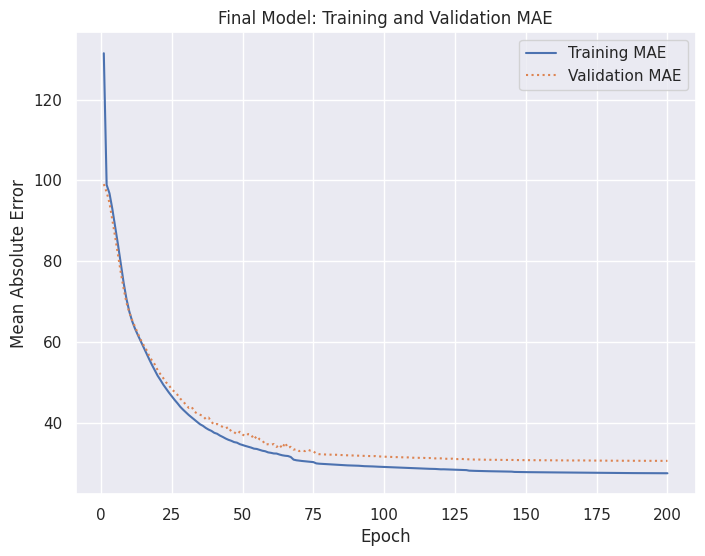

109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Final selected model test performance
MAE: 29.98275473395789
RMSE: 48.75955015083088
R-squared: 0.9249182742125267


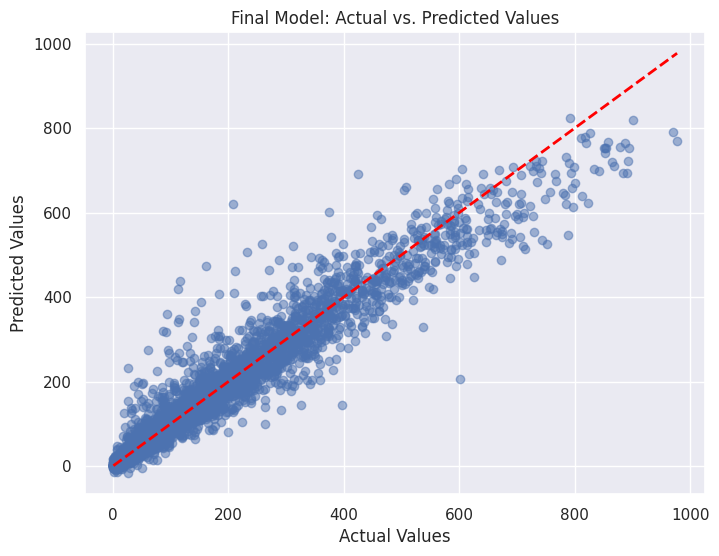

In [24]:
# ============================================================
# Assignment 4 - Final selected neural network
# Architecture: 128 -> 64
# Dropout: 0.0
# ============================================================

import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import backend as K

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

K.clear_session()
tf.keras.utils.set_random_seed(42)


# ------------------------------------------------------------
# Build final model
# ------------------------------------------------------------

final_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)
])

final_model.compile(
    optimizer='adam',
    loss='mae',
    metrics=['mae']
)

final_model.summary()


# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_mae',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=3
)

final_filepath = "best_final_model.keras"

checkpoint = ModelCheckpoint(
    final_filepath,
    monitor='val_mae',
    mode='min',
    save_best_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Train final model
# ------------------------------------------------------------

final_history = final_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=0
)


# ------------------------------------------------------------
# Training information
# ------------------------------------------------------------

training_mae = final_history.history['mae']
validation_mae = final_history.history['val_mae']

best_epoch = validation_mae.index(min(validation_mae)) + 1
best_validation_mae = min(validation_mae)

print(f"Epochs trained: {len(validation_mae)}")
print(f"Best epoch: {best_epoch}")
print(f"Best validation MAE: {best_validation_mae:.4f}")


# ------------------------------------------------------------
# Training and validation curve
# ------------------------------------------------------------

epochs = range(1, len(training_mae) + 1)

plt.figure(figsize=(8, 6))
plt.plot(epochs, training_mae, label='Training MAE')
plt.plot(epochs, validation_mae, ':', label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('Mean Absolute Error')
plt.title('Final Model: Training and Validation MAE')
plt.legend()
plt.show()


# ------------------------------------------------------------
# Load best saved model and evaluate on test set
# ------------------------------------------------------------

final_model = load_model(final_filepath)

y_pred_final = final_model.predict(X_test_scaled)

final_mae = mean_absolute_error(y_test, y_pred_final)
final_rmse = root_mean_squared_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print("\nFinal selected model test performance")
print(f"MAE: {final_mae}")
print(f"RMSE: {final_rmse}")
print(f"R-squared: {final_r2}")


# ------------------------------------------------------------
# Actual vs predicted values
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.5)

plt.plot(
    [min(y_test), max(y_test)],
    [min(y_test), max(y_test)],
    linestyle='--',
    color='red',
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Final Model: Actual vs. Predicted Values")
plt.show()

### Final model comparison

| Model / experiment | Architecture | Dropout | Best validation MAE | Test MAE | Test RMSE | Test R² |
|---|---|---:|---:|---:|---:|---:|
| Task 2 baseline | 32 → 64 | 0.0 | 35.0489 | 33.3423 | 55.0442 | 0.9043 |
| Architecture test | 64 → 64 | 0.0 | 32.2398 | – | – | – |
| Architecture test | 64 → 128 | 0.0 | 32.4739 | – | – | – |
| Architecture test | 128 → 128 | 0.0 | 32.4861 | – | – | – |
| **Selected architecture** | **128 → 64** | **0.0** | **30.6675** | **29.9828** | **48.7596** | **0.9249** |
| Dropout test | 128 → 64 | 0.1 | 40.8448 | – | – | – |
| Dropout test | 128 → 64 | 0.2 | 55.9767 | – | – | – |
| Dropout test | 128 → 64 | 0.3 | 62.6670 | – | – | – |

The 128 → 64 network without dropout produced the lowest validation MAE and was therefore selected as the final model. Adding dropout reduced performance for all tested dropout rates. The final selected model also improved the test performance compared with the original 32 → 64 baseline.